# 02: Data Cleaning
### Stack Overflow Developer Survey: Curriculum Optimization for High-Yield Tech Stacks

**Name:** Sara AlNajjar  
**Cohort:** General Assembly Data Science, DSBFT2  
**Project:** Project 2: Exploratory Data Analysis


## 1. Imports & Raw Data

In [20]:
import pandas as pd
import numpy as np

In [21]:
# Reload raw data
df24 = pd.read_csv('../Data/Survey 2024/survey_results_2024.csv', low_memory=False)
df25 = pd.read_csv('../Data/Survey 2025/survey_results_2025.csv', low_memory=False)

## 2. Confirm Required Columns

Based on the schema comparison in `01_Data_Collection.ipynb`, confirm the columns this analysis depends on are present and identically named in both years.

In [22]:
# Confirm columns this analysis depends on exist in both years
needed_cols = ['ResponseId', 'Country', 'EdLevel', 'DevType', 'OrgSize',
               'LanguageHaveWorkedWith', 'ConvertedCompYearly']

for col in needed_cols:
    print(f"{col:25} | 2024: {col in df24.columns} | 2025: {col in df25.columns}")

ResponseId                | 2024: True | 2025: True
Country                   | 2024: True | 2025: True
EdLevel                   | 2024: True | 2025: True
DevType                   | 2024: True | 2025: True
OrgSize                   | 2024: True | 2025: True
LanguageHaveWorkedWith    | 2024: True | 2025: True
ConvertedCompYearly       | 2024: True | 2025: True


## 3. Filter to Scope: United States Respondents

Filtering both years to US respondents controls for currency and cost-of-living disparities across countries, so compensation comparisons by language stay meaningful.

In [23]:
# Restrict both years to US respondents
df24_us = df24[df24['Country'] == 'United States of America'].copy()
df25_us = df25[df25['Country'] == 'United States of America'].copy()

df24_us.shape, df25_us.shape

((11095, 114), (7233, 172))

## 4. Column Selection

Subsetting to the fields this analysis actually needs, rather than carrying all 114-172 columns forward.

In [24]:
df24_sub = df24_us[needed_cols].copy()
df25_sub = df25_us[needed_cols].copy()

## 5. Combine Years

Tagging each row with its survey year before concatenating, so year-over-year compensation growth by language can still be examined after the merge.

In [25]:
# Tag each row with its survey year before combining
df24_sub['SurveyYear'] = 2024
df25_sub['SurveyYear'] = 2025

df = pd.concat([df24_sub, df25_sub], ignore_index=True)
df.shape

(18328, 8)

In [26]:
# Sanity check: combined row count should equal the sum of both years
len(df) == len(df24_sub) + len(df25_sub)

True

## 6. Missing Data

Reviewing null counts before deciding what to drop or leave as-is.

In [27]:
df.isnull().sum().sort_values(ascending=False)

ConvertedCompYearly       8408
OrgSize                   3593
LanguageHaveWorkedWith     804
DevType                    134
EdLevel                     23
ResponseId                   0
Country                      0
SurveyYear                   0
dtype: int64

*Missing-data decision: dropping rows with no `LanguageHaveWorkedWith` or `ConvertedCompYearly`, since both are required for this analysis and can't be meaningfully imputed. `ConvertedCompYearly` has a high null rate because compensation is an optional survey field.*

In [28]:
# Drop respondents missing either required field
df_clean = df.dropna(subset=['LanguageHaveWorkedWith', 'ConvertedCompYearly']).copy()
df_clean.shape

(9632, 8)

## 7. Outlier Handling: `ConvertedCompYearly`

Self-reported compensation fields typically include extreme low/high entries from data entry errors. Inspecting the distribution before applying any cutoff.

In [29]:
df_clean['ConvertedCompYearly'].describe()

count    9.632000e+03
mean     1.652872e+05
std      1.255552e+05
min      1.000000e+00
25%      1.020000e+05
50%      1.472500e+05
75%      2.000000e+05
max      3.900000e+06
Name: ConvertedCompYearly, dtype: float64

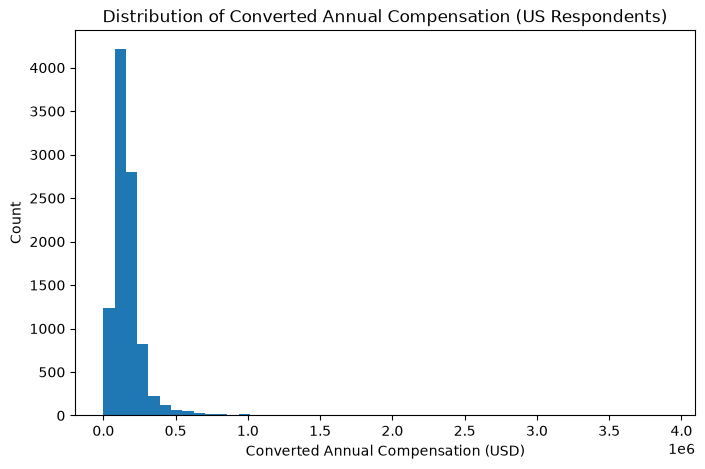

In [30]:
import matplotlib.pyplot as plt

# Visualize the compensation distribution to spot extreme entries
plt.figure(figsize=(8, 5))
plt.hist(df_clean['ConvertedCompYearly'], bins=50)
plt.xlabel('Converted Annual Compensation (USD)')
plt.ylabel('Count')
plt.title('Distribution of Converted Annual Compensation (US Respondents)')
plt.show()

*Dropping compensation below `$15,000` or above `$1,000,000` as likely data entry errors, based on the distribution above, not an arbitrary number.*

In [31]:
LOWER_BOUND = 15_000
UPPER_BOUND = 1_000_000

df_clean = df_clean[
    (df_clean['ConvertedCompYearly'] >= LOWER_BOUND) &
    (df_clean['ConvertedCompYearly'] <= UPPER_BOUND)
].copy()

df_clean.shape

(9453, 8)

## 8. Export Cleaned Data

Saving the cleaned, combined dataset to `Data/Cleaned/` so `03_EDA.ipynb` can load it directly without repeating the collection and cleaning steps.

In [32]:
import os

# Create the Cleaned data folder if it doesn't already exist, then export
os.makedirs('../Data/Cleaned', exist_ok=True)
df_clean.to_csv('../Data/Cleaned/stack_overflow_cleaned.csv', index=False)

print(f"Saved {df_clean.shape[0]} rows and {df_clean.shape[1]} columns to "
      "../Data/Cleaned/stack_overflow_cleaned.csv")

Saved 9453 rows and 8 columns to ../Data/Cleaned/stack_overflow_cleaned.csv
